In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df.drop('Species',axis = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

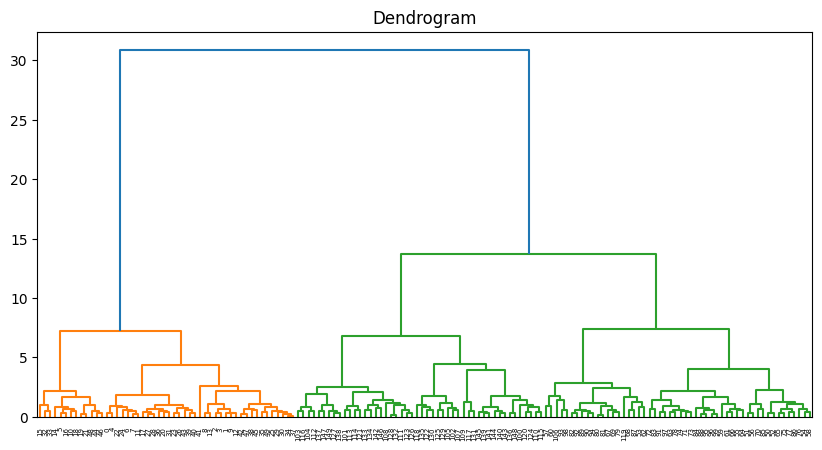

In [ ]:
linked = linkage(X_scaled,method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [ ]:
hc=AgglomerativeClustering(n_clusters=3)
hc_labels=hc.fit_predict(X_scaled)
df['HC_Cluster']=hc_labels

In [ ]:
hc_score=silhouette_score(X_scaled,hc_labels)
print("Hierchical Clustering Score:",hc_score)


Hierchical Clustering Score: 0.45183200660097467


In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
km_labels=kmeans.fit_predict(X_scaled)
df['KM_Cluster']=km_labels
km_score=silhouette_score(X_scaled,km_labels)
print("K-Means Silhouette Score:",km_score)

K-Means Silhouette Score: 0.452949780355554


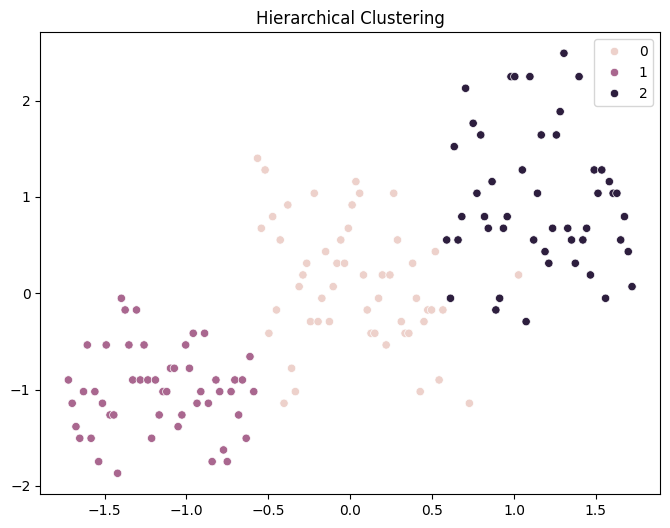

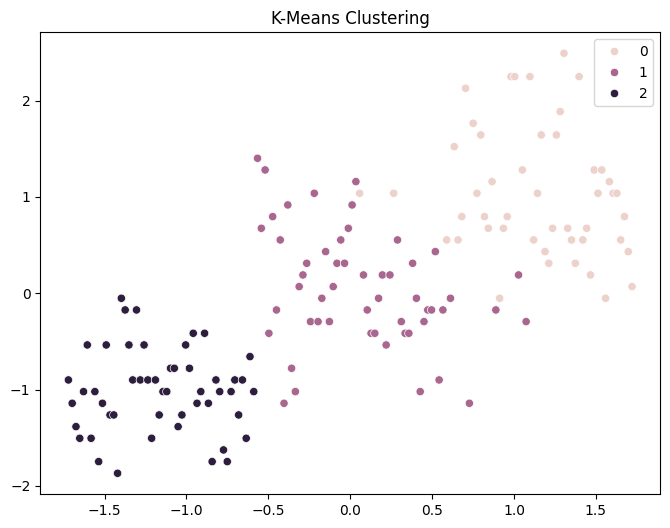

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hierarchical Clustering Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

# K-Means Clustering Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=km_labels)
plt.title("K-Means Clustering")
plt.show()